<a href="https://colab.research.google.com/github/Mparna/my-colab-project/blob/main/semiconductor_wafer_yield_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn plotly streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 83.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import plotly

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "secom" in file.lower():
            print(os.path.join(root, file))

/content/sample_data/secom.data
/content/sample_data/secom_labels.data


In [ ]:
import pandas as pd

# Load semiconductor process measurements
X = pd.read_csv(
    "/content/sample_data/secom.data",
    sep=r"\s+",
    header=None
)

# Load manufacturing labels
y = pd.read_csv(
    "/content/sample_data/secom_labels.data",
    sep=r"\s+",
    header=None
)

print("Process data shape:", X.shape)
print("Label data shape:", y.shape)


Process data shape: (1567, 590)
Label data shape: (1567, 2)


In [ ]:
print(y.head())

   0                    1
0 -1  19/07/2008 11:55:00
1 -1  19/07/2008 12:32:00
2  1  19/07/2008 13:17:00
3 -1  19/07/2008 14:43:00
4 -1  19/07/2008 15:22:00


In [ ]:
print("Label counts:")
print(y[0].value_counts())

Label counts:
0
-1    1463
 1     104
Name: count, dtype: int64


In [ ]:
X.columns = [f"Feature_{i+1}" for i in range(X.shape[1])]

y.columns = ["Result", "Timestamp"]

print(X.head())
print(y.head())

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0    3030.93    2564.00  2187.7333  1411.1265     1.3602      100.0   
1    3095.78    2465.14  2230.4222  1463.6606     0.8294      100.0   
2    2932.61    2559.94  2186.4111  1698.0172     1.5102      100.0   
3    2988.72    2479.90  2199.0333   909.7926     1.3204      100.0   
4    3032.24    2502.87  2233.3667  1326.5200     1.5334      100.0   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_581  Feature_582  \
0    97.6133     0.1242     1.5005      0.0162  ...          NaN          NaN   
1   102.3433     0.1247     1.4966     -0.0005  ...       0.0060     208.2045   
2    95.4878     0.1241     1.4436      0.0041  ...       0.0148      82.8602   
3   104.2367     0.1217     1.4882     -0.0124  ...       0.0044      73.8432   
4   100.3967     0.1235     1.5031     -0.0031  ...          NaN          NaN   

   Feature_583  Feature_584  Feature_585  Feature_586  Feature_587  \
0       0.5005  

In [ ]:
df = X.copy()

df["Result"] = y["Result"].values
df["Timestamp"] = y["Timestamp"].values

print("Final dataset shape:", df.shape)

Final dataset shape: (1567, 592)


In [ ]:
# Count each manufacturing result
result_counts = df["Result"].value_counts()

print("Manufacturing Results:")
print(result_counts)

# Calculate total observations
total = len(df)

# In SECOM, -1 represents a passing observation
pass_count = (df["Result"] == -1).sum()

# 1 represents a failing observation
fail_count = (df["Result"] == 1).sum()

# Calculate yield
yield_percent = (pass_count / total) * 100

print("\nTotal observations:", total)
print("Pass:", pass_count)
print("Fail:", fail_count)
print(f"Yield: {yield_percent:.2f}%")


Manufacturing Results:
Result
-1    1463
 1     104
Name: count, dtype: int64

Total observations: 1567
Pass: 1463
Fail: 104
Yield: 93.36%


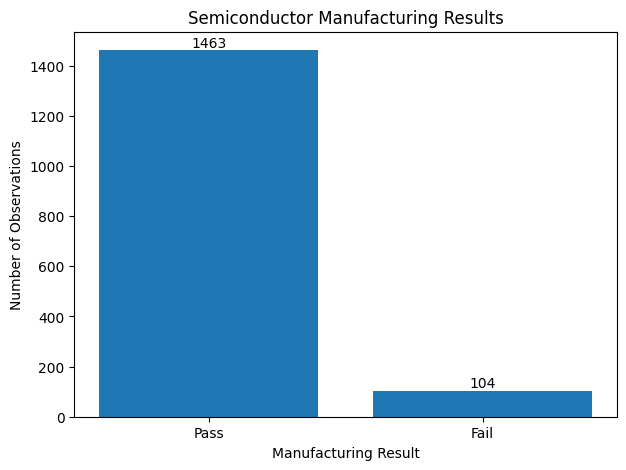

In [ ]:
import matplotlib.pyplot as plt

# Get pass/fail counts
result_counts = df["Result"].value_counts()

# Rename the results
labels = ["Pass", "Fail"]
values = [
    result_counts.get(-1, 0),
    result_counts.get(1, 0)
]

# Create bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.title("Semiconductor Manufacturing Results")
plt.xlabel("Manufacturing Result")
plt.ylabel("Number of Observations")

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.show()


In [ ]:
# Count missing values in every process feature
missing_values = X.isna().sum()

# Sort from most missing to least missing
missing_values = missing_values.sort_values(ascending=False)

# Show the 20 features with the most missing values
print("Top 20 features with missing values:")
display(missing_values.head(20))


Top 20 features with missing values:


,0
Feature_293,1429
Feature_294,1429
Feature_159,1429
Feature_158,1429
Feature_493,1341
Feature_86,1341
Feature_359,1341
Feature_221,1341
Feature_245,1018
Feature_518,1018


In [ ]:
total_values = X.shape[0] * X.shape[1]
total_missing = X.isna().sum().sum()

missing_percent = (total_missing / total_values) * 100

print(f"Total data points: {total_values:,}")
print(f"Missing data points: {total_missing:,}")
print(f"Overall missing percentage: {missing_percent:.2f}%")


Total data points: 924,530
Missing data points: 41,951
Overall missing percentage: 4.54%


In [ ]:
missing_percentage = X.isna().mean() * 100

print("Features with more than 20% missing values:")
print((missing_percentage > 20).sum())

print("\nFeatures with more than 40% missing values:")
print((missing_percentage > 40).sum())

print("\nFeatures with more than 50% missing values:")
print((missing_percentage > 50).sum())


Features with more than 20% missing values:
32

Features with more than 40% missing values:
32

Features with more than 50% missing values:
28


In [ ]:
# Calculate percentage of missing values for each feature
missing_percentage = X.isna().mean() * 100

# Keep features with 50% or less missing data
X_clean = X.loc[:, missing_percentage <= 50]

print("Original number of features:", X.shape[1])
print("Features after removing >50% missing:", X_clean.shape[1])
print("Features removed:", X.shape[1] - X_clean.shape[1])


Original number of features: 590
Features after removing >50% missing: 562
Features removed: 28


In [ ]:
from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy="median")

# Fill remaining missing values
X_clean = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns
)

print("Remaining missing values:", X_clean.isna().sum().sum())


Remaining missing values: 0


In [ ]:
print("Clean dataset shape:", X_clean.shape)

print("\nMissing values remaining:")
print(X_clean.isna().sum().sum())


Clean dataset shape: (1567, 562)

Missing values remaining:
0


In [ ]:
# Create a copy of the cleaned process data
analysis_df = X_clean.copy()

# Add manufacturing result
analysis_df["Result"] = y["Result"].values

# Create an easy-to-read failure column
analysis_df["Failure"] = (analysis_df["Result"] == 1).astype(int)

print("Analysis dataset shape:", analysis_df.shape)

display(analysis_df.head())


Analysis dataset shape: (1567, 564)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_583,Feature_584,Feature_585,Feature_586,Feature_587,Feature_588,Feature_589,Feature_590,Result,Failure
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,0


In [ ]:
# Separate passing and failing observations
pass_data = analysis_df[analysis_df["Failure"] == 0]
fail_data = analysis_df[analysis_df["Failure"] == 1]

print("Passing observations:", len(pass_data))
print("Failing observations:", len(fail_data))


Passing observations: 1463
Failing observations: 104


In [ ]:
feature_columns = X_clean.columns

pass_mean = pass_data[feature_columns].mean()
fail_mean = fail_data[feature_columns].mean()

comparison = pd.DataFrame({
    "Pass_Mean": pass_mean,
    "Fail_Mean": fail_mean
})

comparison["Absolute_Difference"] = (
    comparison["Fail_Mean"] - comparison["Pass_Mean"]
).abs()

comparison = comparison.sort_values(
    "Absolute_Difference",
    ascending=False
)

display(comparison.head(20))


,Pass_Mean,Fail_Mean,Absolute_Difference
Feature_162,4087.887218,3742.980769,344.906449
Feature_160,862.112098,1167.028846,304.916748
Feature_22,-5636.360219,-5363.822115,272.538103
Feature_25,-284.300923,-495.493587,211.192664
Feature_161,541.533835,747.394231,205.860396
Feature_163,4805.227614,4625.644231,179.583384
Feature_295,391.341226,546.780908,155.439682
Feature_297,1887.069816,1755.904619,131.165197
Feature_296,246.024680,350.011196,103.986516
Feature_23,2705.130041,2617.788462,87.341579


In [ ]:
top_feature = comparison.index[0]

print("Top feature:", top_feature)


Top feature: Feature_162


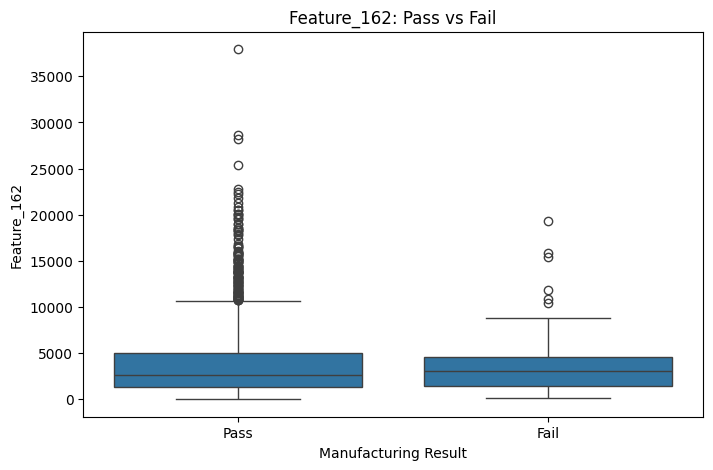

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="Failure",
    y=top_feature
)

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.title(f"{top_feature}: Pass vs Fail")
plt.xlabel("Manufacturing Result")
plt.ylabel(top_feature)

plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# Store statistical test results
stat_results = []

for feature in X_clean.columns:

    pass_values = pass_data[feature]
    fail_values = fail_data[feature]

    # Mann-Whitney U test
    statistic, p_value = mannwhitneyu(
        pass_values,
        fail_values,
        alternative="two-sided"
    )

    stat_results.append({
        "Feature": feature,
        "U_Statistic": statistic,
        "P_Value": p_value
    })

# Convert results into DataFrame
stats_df = pd.DataFrame(stat_results)

# Sort by p-value
stats_df = stats_df.sort_values("P_Value")

display(stats_df.head(20))


,Feature,U_Statistic,P_Value
59,Feature_60,46800.5,5.181701e-11
100,Feature_104,50481.0,9.434706e-09
235,Feature_248,55308.5,9.788141e-07
495,Feature_520,55350.5,1.029350e-06
489,Feature_511,55369.5,3.420323e-06
457,Feature_478,57607.0,3.442858e-05
123,Feature_130,57933.5,4.644758e-05
197,Feature_206,57919.5,4.662632e-05
28,Feature_29,93740.5,7.445539e-05
365,Feature_386,60009.0,1.474187e-04


In [ ]:
feature_162_result = stats_df[
    stats_df["Feature"] == "Feature_162"
]

display(feature_162_result)


,Feature,U_Statistic,P_Value
153,Feature_162,74375.5,0.703006


In [ ]:
significant_features = stats_df[
    stats_df["P_Value"] < 0.05
]

print(
    "Number of statistically significant features:",
    len(significant_features)
)

display(significant_features.head(20))


Number of statistically significant features: 86


,Feature,U_Statistic,P_Value
59,Feature_60,46800.5,5.181701e-11
100,Feature_104,50481.0,9.434706e-09
235,Feature_248,55308.5,9.788141e-07
495,Feature_520,55350.5,1.029350e-06
489,Feature_511,55369.5,3.420323e-06
457,Feature_478,57607.0,3.442858e-05
123,Feature_130,57933.5,4.644758e-05
197,Feature_206,57919.5,4.662632e-05
28,Feature_29,93740.5,7.445539e-05
365,Feature_386,60009.0,1.474187e-04


In [ ]:
from statsmodels.stats.multitest import multipletests


In [ ]:
# Apply Benjamini-Hochberg FDR correction
rejected, adjusted_pvalues, _, _ = multipletests(
    stats_df["P_Value"],
    alpha=0.05,
    method="fdr_bh"
)

stats_df["Adjusted_P_Value"] = adjusted_pvalues
stats_df["Significant_FDR"] = rejected

# Sort by adjusted p-value
stats_df = stats_df.sort_values("Adjusted_P_Value")

display(stats_df.head(20))


,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant_FDR
59,Feature_60,46800.5,5.181701e-11,2.912116e-08,True
100,Feature_104,50481.0,9.434706e-09,2.651152e-06,True
495,Feature_520,55350.5,1.029350e-06,1.446237e-04,True
235,Feature_248,55308.5,9.788141e-07,1.446237e-04,True
489,Feature_511,55369.5,3.420323e-06,3.844443e-04,True
457,Feature_478,57607.0,3.442858e-05,3.224810e-03,True
197,Feature_206,57919.5,4.662632e-05,3.275499e-03,True
123,Feature_130,57933.5,4.644758e-05,3.275499e-03,True
28,Feature_29,93740.5,7.445539e-05,4.649326e-03,True
365,Feature_386,60009.0,1.474187e-04,8.222347e-03,True


In [ ]:
significant_fdr = stats_df[
    stats_df["Significant_FDR"]
]

print(
    "Features significant after FDR correction:",
    len(significant_fdr)
)

display(significant_fdr.head(20))


Features significant after FDR correction: 20


,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant_FDR
59,Feature_60,46800.5,5.181701e-11,2.912116e-08,True
100,Feature_104,50481.0,9.434706e-09,2.651152e-06,True
495,Feature_520,55350.5,1.029350e-06,1.446237e-04,True
235,Feature_248,55308.5,9.788141e-07,1.446237e-04,True
489,Feature_511,55369.5,3.420323e-06,3.844443e-04,True
457,Feature_478,57607.0,3.442858e-05,3.224810e-03,True
197,Feature_206,57919.5,4.662632e-05,3.275499e-03,True
123,Feature_130,57933.5,4.644758e-05,3.275499e-03,True
28,Feature_29,93740.5,7.445539e-05,4.649326e-03,True
365,Feature_386,60009.0,1.474187e-04,8.222347e-03,True


In [ ]:
display(
    stats_df[
        stats_df["Feature"] == "Feature_162"
    ]
)


,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant_FDR
153,Feature_162,74375.5,0.703006,1.0,False


In [ ]:
# Count features that remain significant after FDR correction
significant_fdr = stats_df[
    stats_df["Significant_FDR"] == True
]

print(
    "Features significant after FDR correction:",
    len(significant_fdr)
)

display(significant_fdr.head(20))


Features significant after FDR correction: 20


,Feature,U_Statistic,P_Value,Adjusted_P_Value,Significant_FDR
59,Feature_60,46800.5,5.181701e-11,2.912116e-08,True
100,Feature_104,50481.0,9.434706e-09,2.651152e-06,True
495,Feature_520,55350.5,1.029350e-06,1.446237e-04,True
235,Feature_248,55308.5,9.788141e-07,1.446237e-04,True
489,Feature_511,55369.5,3.420323e-06,3.844443e-04,True
457,Feature_478,57607.0,3.442858e-05,3.224810e-03,True
197,Feature_206,57919.5,4.662632e-05,3.275499e-03,True
123,Feature_130,57933.5,4.644758e-05,3.275499e-03,True
28,Feature_29,93740.5,7.445539e-05,4.649326e-03,True
365,Feature_386,60009.0,1.474187e-04,8.222347e-03,True


In [ ]:
import numpy as np

effect_results = []

for feature in X_clean.columns:

    pass_values = pass_data[feature].values
    fail_values = fail_data[feature].values

    # Means
    mean_pass = np.mean(pass_values)
    mean_fail = np.mean(fail_values)

    # Standard deviations
    std_pass = np.std(pass_values, ddof=1)
    std_fail = np.std(fail_values, ddof=1)

    # Sample sizes
    n_pass = len(pass_values)
    n_fail = len(fail_values)

    # Pooled standard deviation
    pooled_std = np.sqrt(
        (
            (n_pass - 1) * std_pass**2
            + (n_fail - 1) * std_fail**2
        )
        / (n_pass + n_fail - 2)
    )

    # Cohen's d
    if pooled_std != 0:
        cohens_d = (mean_fail - mean_pass) / pooled_std
    else:
        cohens_d = 0

    effect_results.append({
        "Feature": feature,
        "Pass_Mean": mean_pass,
        "Fail_Mean": mean_fail,
        "Cohens_d": cohens_d,
        "Absolute_Cohens_d": abs(cohens_d)
    })

effect_df = pd.DataFrame(effect_results)

# Combine statistical and effect-size results
final_feature_analysis = stats_df.merge(
    effect_df,
    on="Feature"
)

# Sort by absolute effect size
final_feature_analysis = final_feature_analysis.sort_values(
    "Absolute_Cohens_d",
    ascending=False
)

display(
    final_feature_analysis[
        [
            "Feature",
            "Pass_Mean",
            "Fail_Mean",
            "Cohens_d",
            "P_Value",
            "Adjusted_P_Value",
            "Significant_FDR"
        ]
    ].head(20)
)


,Feature,Pass_Mean,Fail_Mean,Cohens_d,P_Value,Adjusted_P_Value,Significant_FDR
0,Feature_60,2.555731,8.515123,0.634087,5.181701e-11,2.912116e-08,True
1,Feature_104,-0.009913,-0.008053,0.614206,9.434706e-09,2.651152e-06,True
4,Feature_511,54.430401,74.347949,0.533225,3.420323e-06,3.844443e-04,True
17,Feature_349,0.024263,0.030448,0.529701,1.496108e-03,4.482891e-02,True
22,Feature_432,21.187933,38.707342,0.485010,2.735794e-03,6.297974e-02,False
53,Feature_435,13.716830,28.954783,0.449677,2.040153e-02,2.123270e-01,False
78,Feature_431,17.364169,33.156115,0.440694,4.116126e-02,2.928181e-01,False
13,Feature_22,-5636.360219,-5363.822115,0.437501,4.677745e-04,1.815607e-02,True
177,Feature_436,8.373389,23.306973,0.437200,2.397372e-01,7.569230e-01,False
8,Feature_29,69.597730,68.111542,-0.432002,7.445539e-05,4.649326e-03,True


In [ ]:
candidate_features = final_feature_analysis[
    (final_feature_analysis["Significant_FDR"] == True) &
    (final_feature_analysis["Absolute_Cohens_d"] >= 0.5)
]

print(
    "Candidate features:",
    len(candidate_features)
)

display(
    candidate_features[
        [
            "Feature",
            "Pass_Mean",
            "Fail_Mean",
            "Cohens_d",
            "P_Value",
            "Adjusted_P_Value"
        ]
    ]
)


Candidate features: 4


,Feature,Pass_Mean,Fail_Mean,Cohens_d,P_Value,Adjusted_P_Value
0,Feature_60,2.555731,8.515123,0.634087,5.181701e-11,2.912116e-08
1,Feature_104,-0.009913,-0.008053,0.614206,9.434706e-09,2.651152e-06
4,Feature_511,54.430401,74.347949,0.533225,3.420323e-06,3.844443e-04
17,Feature_349,0.024263,0.030448,0.529701,1.496108e-03,4.482891e-02


In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = X_clean.copy()

# Target: 0 = Pass, 1 = Fail
y = analysis_df["Failure"].copy()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())


Training set: (1253, 562)
Test set: (314, 562)

Training class distribution:
Failure
0    1170
1      83
Name: count, dtype: int64

Test class distribution:
Failure
0    293
1     21
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)


Training data shape: (1253, 562)
Test data shape: (314, 562)


In [ ]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTest class percentages:")
print(y_test.value_counts(normalize=True) * 100)


Training class distribution:
Failure
0    1170
1      83
Name: count, dtype: int64

Training class percentages:
Failure
0    93.375898
1     6.624102
Name: proportion, dtype: float64

Test class distribution:
Failure
0    293
1     21
Name: count, dtype: int64

Test class percentages:
Failure
0    93.312102
1     6.687898
Name: proportion, dtype: float64


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print("Training data after feature selection:", X_train_selected.shape)
print("Test data after feature selection:", X_test_selected.shape)


Training data after feature selection: (1253, 50)
Test data after feature selection: (314, 50)


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  5  13  42  49  52  69  94 135 143 170 171 178 181 182 183 184 185 186
 217 220 221 222 223 224 225 226 227 228 231 232 233 234 244 245 246 247
 248 249 250 251 252 253 254 264 272 299 300 301 308 311 312 313 314 315
 316 347 352 353 354 355 356 357 358 361 362 363 364 374 375 376 377 378
 379 380 381 382 383 384 394 402 429 430 431 438 441 442 443 444 445 446
 461 477 480 481 482 483 484 485 486 487 488 491 492 493 494 504 505 506
 507 508 509 510 511 512 513 514] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with zero variance
variance_selector = VarianceThreshold(threshold=0)

X_train_var = variance_selector.fit_transform(X_train_scaled)
X_test_var = variance_selector.transform(X_test_scaled)

print("Before removing constant features:", X_train_scaled.shape)
print("After removing constant features:", X_train_var.shape)


Before removing constant features: (1253, 562)
After removing constant features: (1253, 446)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

k = min(50, X_train_var.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_var,
    y_train
)

X_test_selected = selector.transform(
    X_test_var
)

print("Selected training features:", X_train_selected.shape)
print("Selected test features:", X_test_selected.shape)


Selected training features: (1253, 50)
Selected test features: (314, 50)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# Train the model
model.fit(X_train_selected, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = model.predict(X_test_selected)
y_prob = model.predict_proba(X_test_selected)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Pass", "Fail"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.7452229299363057
Precision: 0.12658227848101267
Recall   : 0.47619047619047616
F1 Score : 0.2
ROC-AUC  : 0.682106289614822

Classification Report:
              precision    recall  f1-score   support

        Pass       0.95      0.76      0.85       293
        Fail       0.13      0.48      0.20        21

    accuracy                           0.75       314
   macro avg       0.54      0.62      0.52       314
weighted avg       0.90      0.75      0.81       314


Confusion Matrix:
[[224  69]
 [ 11  10]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train Random Forest
rf_model.fit(X_train_selected, y_train)

print("Random Forest trained successfully.")


Random Forest trained successfully.


In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test_selected)
rf_prob = rf_model.predict_proba(X_test_selected)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall   :", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, rf_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Pass", "Fail"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


Accuracy : 0.9331210191082803
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.7697870957256624

Classification Report:
              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314


Confusion Matrix:
[[293   0]
 [ 21   0]]


Minimum probability: 0.0
Maximum probability: 0.39
Mean probability: 0.0609235668789809


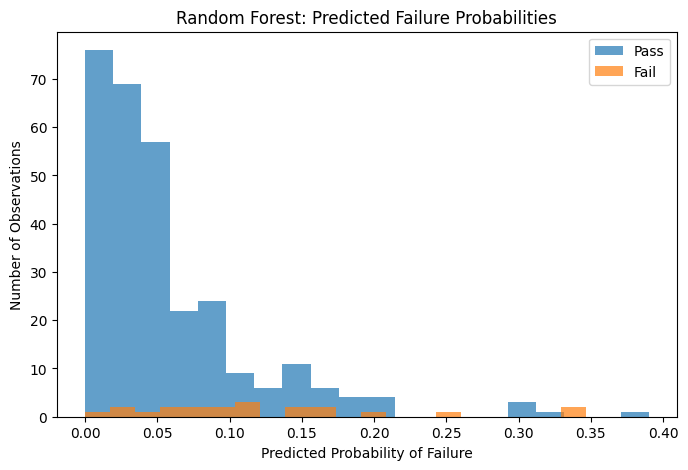

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Look at predicted probabilities for failures
print("Minimum probability:", rf_prob.min())
print("Maximum probability:", rf_prob.max())
print("Mean probability:", rf_prob.mean())

# Distribution of predicted probabilities
plt.figure(figsize=(8, 5))

plt.hist(
    rf_prob[y_test == 0],
    bins=20,
    alpha=0.7,
    label="Pass"
)

plt.hist(
    rf_prob[y_test == 1],
    bins=20,
    alpha=0.7,
    label="Fail"
)

plt.xlabel("Predicted Probability of Failure")
plt.ylabel("Number of Observations")
plt.title("Random Forest: Predicted Failure Probabilities")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)


,Threshold,Precision,Recall,F1
0,0.10,0.196429,0.523810,0.285714
1,0.15,0.222222,0.285714,0.250000
2,0.20,0.333333,0.190476,0.242424
3,0.25,0.285714,0.095238,0.142857
4,0.30,0.400000,0.095238,0.153846
5,0.35,0.000000,0.000000,0.000000
6,0.40,0.000000,0.000000,0.000000
7,0.45,0.000000,0.000000,0.000000
8,0.50,0.000000,0.000000,0.000000


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    rf_model,
    X_train_selected,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:")
print(cv_auc)

print("\nMean ROC-AUC:", cv_auc.mean())
print("Standard deviation:", cv_auc.std())


Cross-validation ROC-AUC scores:
[0.76520865 0.75641026 0.80819507 0.7386485  0.69083868]

Mean ROC-AUC: 0.751860231271996
Standard deviation: 0.03813312827875635


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

model.fit(X_train_selected, y_train)

# Probability of failure
y_prob = model.predict_proba(X_test_selected)[:, 1]

# Start with threshold = 0.20
threshold = 0.20
y_pred = (y_prob >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Pass", "Fail"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.410828025477707
Precision: 0.08585858585858586
Recall   : 0.8095238095238095
F1 Score : 0.1552511415525114
ROC-AUC  : 0.682106289614822

Classification Report:
              precision    recall  f1-score   support

        Pass       0.97      0.38      0.55       293
        Fail       0.09      0.81      0.16        21

    accuracy                           0.41       314
   macro avg       0.53      0.60      0.35       314
weighted avg       0.91      0.41      0.52       314


Confusion Matrix:
[[112 181]
 [  4  17]]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.05):

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)


,Threshold,Precision,Recall,F1
0,0.05,0.074205,1.000000,0.138158
1,0.10,0.082353,1.000000,0.152174
2,0.15,0.084821,0.904762,0.155102
3,0.20,0.085859,0.809524,0.155251
4,0.25,0.084337,0.666667,0.149733
5,0.30,0.100719,0.666667,0.175000
6,0.35,0.099174,0.571429,0.169014
7,0.40,0.114286,0.571429,0.190476
8,0.45,0.133333,0.571429,0.216216
9,0.50,0.126582,0.476190,0.200000


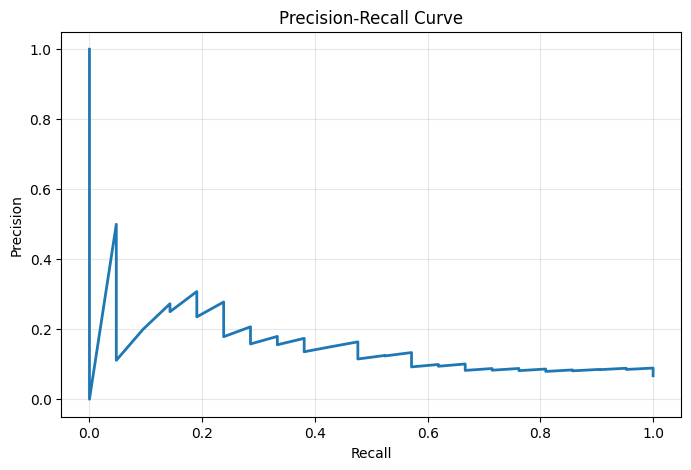

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)

plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300,
        random_state=42
    )
}


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)


PR-AUC: 0.16662119574076992


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    model.fit(X_train_selected, y_train)

    prob = model.predict_proba(X_test_selected)[:, 1]

    # Use 0.20 initially
    pred = (prob >= 0.20).astype(int)

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

model_results = pd.DataFrame(results)

display(
    model_results.sort_values(
        "PR-AUC",
        ascending=False
    )
)


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
1,Random Forest,0.769787,0.233780,0.307692,0.190476,0.235294
0,Logistic Regression,0.682106,0.166621,0.085859,0.809524,0.155251
2,Hist Gradient Boosting,0.674793,0.153813,0.250000,0.047619,0.080000


In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

print("Best threshold:", thresholds[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])


Best threshold: 0.8345304023769602
Precision: 0.2777777777777778
Recall: 0.23809523809523808
F1: 0.25641025636055226


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np
import pandas as pd

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probabilities
cv_prob = cross_val_predict(
    model,
    X_train_selected,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Cross-validated ROC-AUC:",
      roc_auc_score(y_train, cv_prob))

print("Cross-validated PR-AUC:",
      average_precision_score(y_train, cv_prob))


Cross-validated ROC-AUC: 0.7481721758830191
Cross-validated PR-AUC: 0.22304194433750368


In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_train,
    cv_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

final_threshold = thresholds[best_idx]

print("Selected threshold:", final_threshold)
print("CV Precision:", precision[best_idx])
print("CV Recall:", recall[best_idx])
print("CV F1:", f1_scores[best_idx])


Selected threshold: 0.780548980764635
CV Precision: 0.3
CV Recall: 0.3614457831325301
CV F1: 0.3278688524094479


In [ ]:
model.fit(X_train_selected, y_train)

test_prob = model.predict_proba(X_test_selected)[:, 1]

test_pred = (
    test_prob >= final_threshold
).astype(int)

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_prob))

print("Test PR-AUC:",
      average_precision_score(y_test, test_prob))

print("Test Precision:",
      precision_score(y_test, test_pred, zero_division=0))

print("Test Recall:",
      recall_score(y_test, test_pred, zero_division=0))

print("Test F1:",
      f1_score(y_test, test_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))


Test ROC-AUC: 0.682106289614822
Test PR-AUC: 0.16662119574076992
Test Precision: 0.25
Test Recall: 0.23809523809523808
Test F1: 0.24390243902439024

Confusion Matrix:
[[278  15]
 [ 16   5]]


In [ ]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

final_model.fit(X_train_selected, y_train)

print("Final model trained.")


Final model trained.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Create a fresh selector
selector = SelectKBest(
    score_func=f_classif,
    k=50
)

# Fit ONLY on training data
X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

# Apply the SAME selector to test data
X_test_selected = selector.transform(
    X_test
)

# Get the original feature names
selected_features = X_train.columns[
    selector.get_support()
].tolist()

print("Training shape:", X_train_selected.shape)
print("Test shape:", X_test_selected.shape)
print("Number of selected features:", len(selected_features))
print("\nSelected features:")
print(selected_features)


Training shape: (1253, 50)
Test shape: (314, 50)
Number of selected features: 50

Selected features:
['Feature_15', 'Feature_22', 'Feature_23', 'Feature_29', 'Feature_60', 'Feature_64', 'Feature_65', 'Feature_66', 'Feature_71', 'Feature_96', 'Feature_100', 'Feature_101', 'Feature_104', 'Feature_105', 'Feature_115', 'Feature_122', 'Feature_123', 'Feature_125', 'Feature_126', 'Feature_128', 'Feature_130', 'Feature_131', 'Feature_161', 'Feature_164', 'Feature_181', 'Feature_184', 'Feature_211', 'Feature_214', 'Feature_248', 'Feature_250', 'Feature_282', 'Feature_296', 'Feature_299', 'Feature_317', 'Feature_349', 'Feature_352', 'Feature_366', 'Feature_388', 'Feature_431', 'Feature_432', 'Feature_435', 'Feature_436', 'Feature_437', 'Feature_453', 'Feature_456', 'Feature_472', 'Feature_511', 'Feature_512', 'Feature_520', 'Feature_558']


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  5  13  42  49  52  69  94 135 143 170 171 178 181 182 183 184 185 186
 217 220 221 222 223 224 225 226 227 228 231 232 233 234 244 245 246 247
 248 249 250 251 252 253 254 264 272 299 300 301 308 311 312 313 314 315
 316 347 352 353 354 355 356 357 358 361 362 363 364 374 375 376 377 378
 379 380 381 382 383 384 394 402 429 430 431 438 441 442 443 444 445 446
 461 477 480 481 482 483 484 485 486 487 488 491 492 493 494 504 505 506
 507 508 509 510 511 512 513 514] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
import joblib

# Save the trained model
joblib.dump(final_model, "secom_model.pkl")

# Save the imputer
joblib.dump(imputer, "secom_imputer.pkl")

# Save the original cleaned feature column names
joblib.dump(
    list(X_clean.columns),
    "secom_feature_columns.pkl"
)

# Save the 50 selected feature names
joblib.dump(
    selected_features,
    "secom_selected_features.pkl"
)

# Save the classification threshold
joblib.dump(
    final_threshold,
    "secom_threshold.pkl"
)

print("All model files saved successfully.")


All model files saved successfully.


SPC Feature: Feature_15
Center Line: 9.005297064454373
Upper Control Limit: 17.38704524147036
Lower Control Limit: 0.6235488874383854

Out-of-control observations: 6


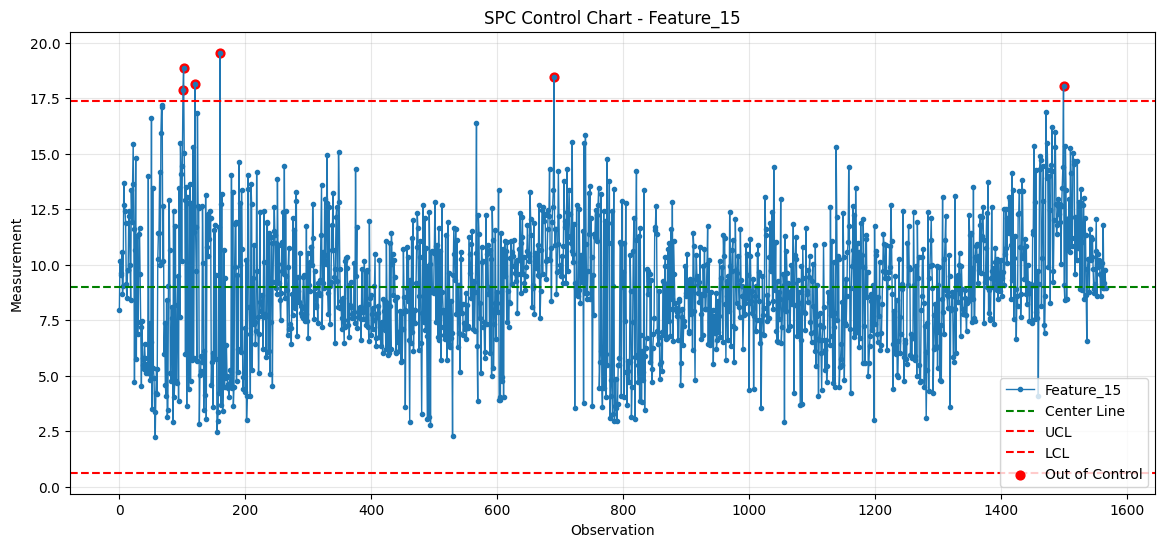

In [ ]:
# ============================================================
# SPC ANALYSIS - STATISTICAL PROCESS CONTROL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select a process feature for SPC
spc_feature = "Feature_15"

# Get the measurements
spc_data = X_clean[spc_feature].dropna()

# Calculate center line and control limits
center_line = spc_data.mean()
std_dev = spc_data.std()

ucl = center_line + 3 * std_dev
lcl = center_line - 3 * std_dev

print("SPC Feature:", spc_feature)
print("Center Line:", center_line)
print("Upper Control Limit:", ucl)
print("Lower Control Limit:", lcl)

# Identify out-of-control observations
out_of_control = (
    (spc_data > ucl) |
    (spc_data < lcl)
)

print("\nOut-of-control observations:",
      out_of_control.sum())

# Plot control chart
plt.figure(figsize=(14, 6))

plt.plot(
    spc_data.values,
    marker="o",
    markersize=3,
    linewidth=1,
    label=spc_feature
)

plt.axhline(
    center_line,
    color="green",
    linestyle="--",
    label="Center Line"
)

plt.axhline(
    ucl,
    color="red",
    linestyle="--",
    label="UCL"
)

plt.axhline(
    lcl,
    color="red",
    linestyle="--",
    label="LCL"
)

# Highlight out-of-control points
out_indices = np.where(out_of_control.values)[0]

plt.scatter(
    out_indices,
    spc_data.iloc[out_indices],
    color="red",
    s=40,
    label="Out of Control"
)

plt.title(f"SPC Control Chart - {spc_feature}")
plt.xlabel("Observation")
plt.ylabel("Measurement")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


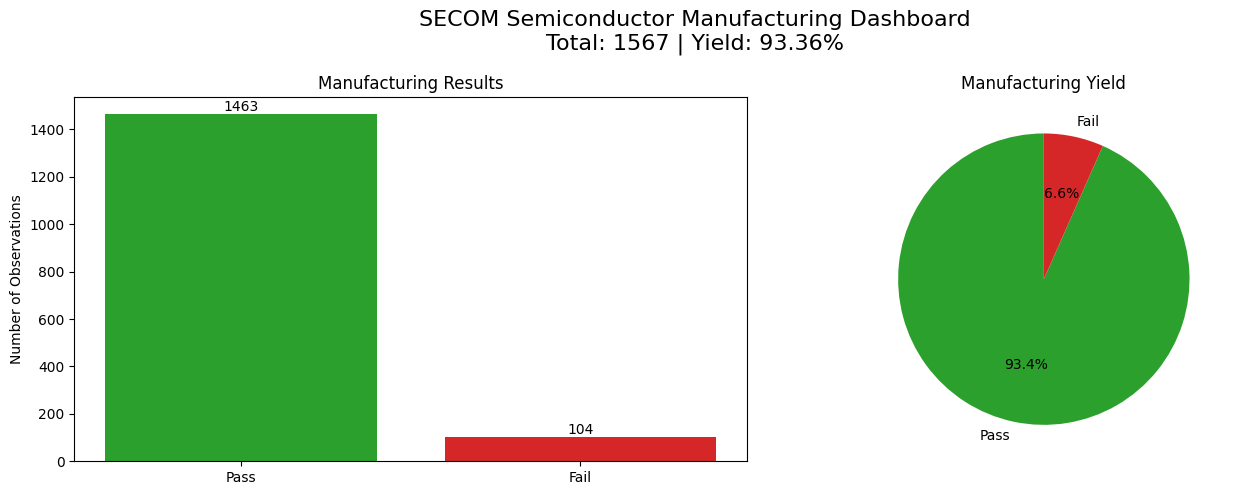

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dashboard data
dashboard_df = analysis_df.copy()

total = len(dashboard_df)
passes = (dashboard_df["Failure"] == 0).sum()
failures = (dashboard_df["Failure"] == 1).sum()
yield_rate = passes / total * 100

# -----------------------------
# Dashboard
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pass / Fail
axes[0].bar(
    ["Pass", "Fail"],
    [passes, failures],
    color=["#2ca02c", "#d62728"]
)

axes[0].set_title("Manufacturing Results")
axes[0].set_ylabel("Number of Observations")

for i, value in enumerate([passes, failures]):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

# Failure percentage
axes[1].pie(
    [passes, failures],
    labels=["Pass", "Fail"],
    autopct="%1.1f%%",
    colors=["#2ca02c", "#d62728"],
    startangle=90
)

axes[1].set_title("Manufacturing Yield")

plt.suptitle(
    f"SECOM Semiconductor Manufacturing Dashboard\n"
    f"Total: {total} | Yield: {yield_rate:.2f}%",
    fontsize=16
)

plt.tight_layout()
plt.show()
